In [12]:
import pandas as pd
import numpy as np

In [13]:
df = pd.read_csv('cleaned_step2 (1).csv')

In [14]:
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,3,No Deposit,14.0,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,4,No Deposit,14.0,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,No Deposit,14.0,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0,No Deposit,304.0,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,No Deposit,240.0,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87388,City Hotel,0,23,2017,August,35,30,2,5,2,...,0,No Deposit,394.0,0,Transient,96.14,0,0,Check-Out,2017-09-06
87389,City Hotel,0,102,2017,August,35,31,2,5,3,...,0,No Deposit,9.0,0,Transient,225.43,0,2,Check-Out,2017-09-07
87390,City Hotel,0,34,2017,August,35,31,2,5,2,...,0,No Deposit,9.0,0,Transient,157.71,0,4,Check-Out,2017-09-07
87391,City Hotel,0,109,2017,August,35,31,2,5,2,...,0,No Deposit,89.0,0,Transient,104.40,0,0,Check-Out,2017-09-07


In [15]:
df['total_stay'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

In [16]:
df['total_guests'] = df['adults'] + df['children'] + df['babies']

In [17]:
df['booking_type'] = np.where(df['lead_time'] > 30, 'Early Booking', 'Last Minute')

In [18]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'total_stay',
       'total_guests', 'booking_type'],
      dtype='object')

In [19]:
def get_season(month):
    if month in ['December', 'January', 'February']:
        return 'Winter'
    elif month in ['March', 'April', 'May']:
        return 'Summer'
    elif month in ['June', 'July', 'August']:
        return 'Monsoon'
    else:
        return 'Autumn'

df['season'] = df['arrival_date_month'].apply(get_season)

In [20]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87393 entries, 0 to 87392
Data columns (total 35 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87393 non-null  object 
 1   is_canceled                     87393 non-null  int64  
 2   lead_time                       87393 non-null  int64  
 3   arrival_date_year               87393 non-null  int64  
 4   arrival_date_month              87393 non-null  object 
 5   arrival_date_week_number        87393 non-null  int64  
 6   arrival_date_day_of_month       87393 non-null  int64  
 7   stays_in_weekend_nights         87393 non-null  int64  
 8   stays_in_week_nights            87393 non-null  int64  
 9   adults                          87393 non-null  int64  
 10  children                        87389 non-null  float64
 11  babies                          87393 non-null  int64  
 12  meal                            

In [21]:
df.to_csv('final_cleaned_hotel_bookings.csv', index=False)

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
sns.set_theme(
    style="whitegrid",
    palette="viridis",
    font_scale=1.1
)

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

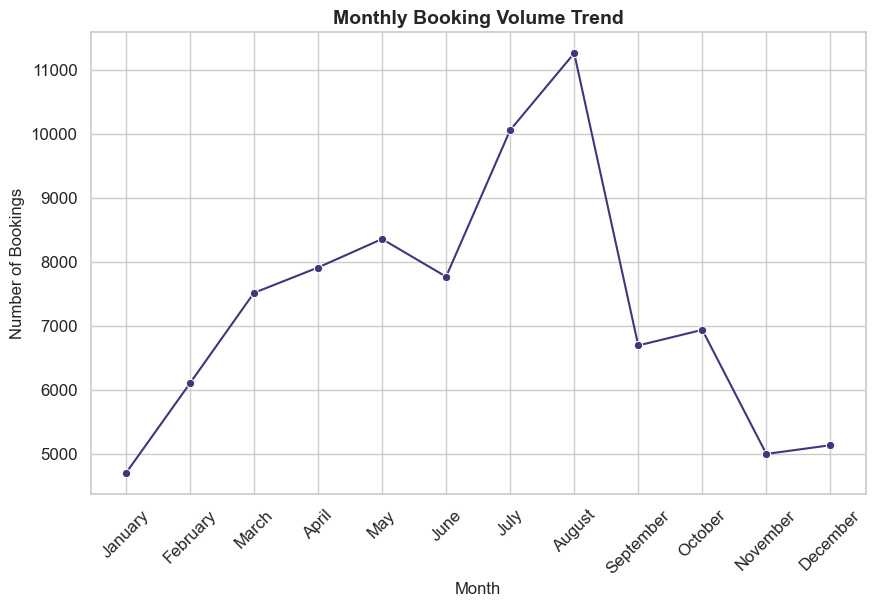

In [41]:
# PERSON - 3 (EDA SECTION 3: SEASONALITY & TRENDS)
# 5. Monthly Booking Volume (Ordered Months)


month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

monthly_bookings = (
    df.groupby('arrival_date_month')
    .size()
    .reindex(month_order)
    .reset_index(name='bookings')
)

plt.figure()
sns.lineplot(
    x='arrival_date_month',
    y='bookings',
    data=monthly_bookings,
    marker='o'
)

plt.title("Monthly Booking Volume Trend")
plt.xlabel("Month")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)
plt.show()

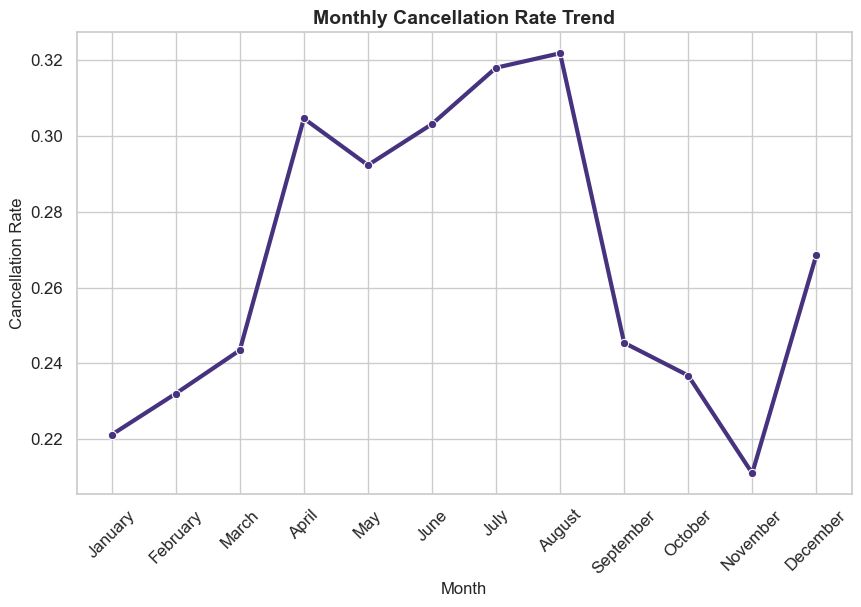

In [42]:
# 6. Monthly Cancellation Rate (Business-Critical Insight)

monthly_cancel = (
    df.groupby('arrival_date_month')['is_canceled']
    .mean()
    .reindex(month_order)
    .reset_index()
)

plt.figure()
sns.lineplot(
    x='arrival_date_month',
    y='is_canceled',
    data=monthly_cancel,
    marker='o',
    linewidth=3
)

plt.title("Monthly Cancellation Rate Trend")
plt.xlabel("Month")
plt.ylabel("Cancellation Rate")
plt.xticks(rotation=45)
plt.show()

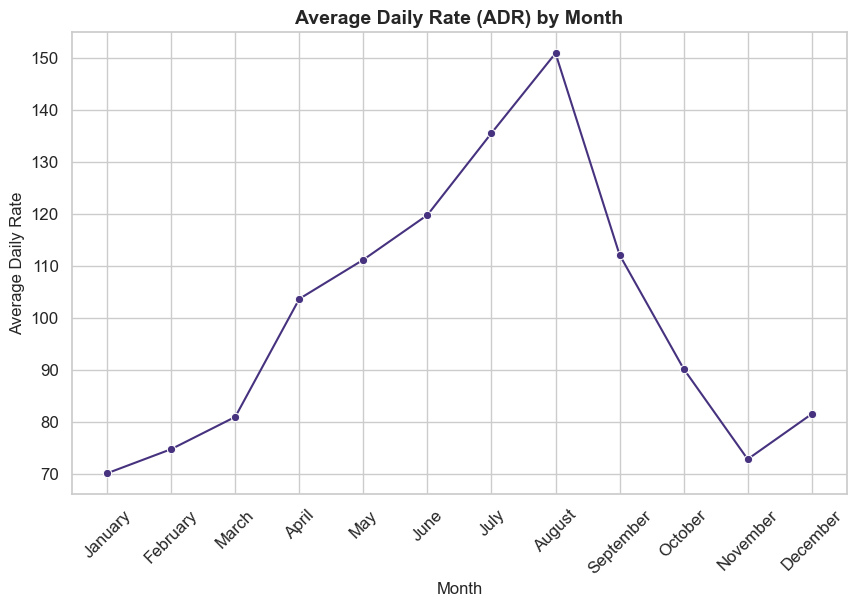

In [43]:
# 7.ADR Seasonality (Pricing Intelligence Plot)

monthly_adr = (
    df.groupby('arrival_date_month')['adr']
    .mean()
    .reindex(month_order)
    .reset_index()
)

plt.figure()
sns.lineplot(
    x='arrival_date_month',
    y='adr',
    data=monthly_adr,
    marker='o'
)

plt.title("Average Daily Rate (ADR) by Month")
plt.xlabel("Month")
plt.ylabel("Average Daily Rate")
plt.xticks(rotation=45)
plt.show()

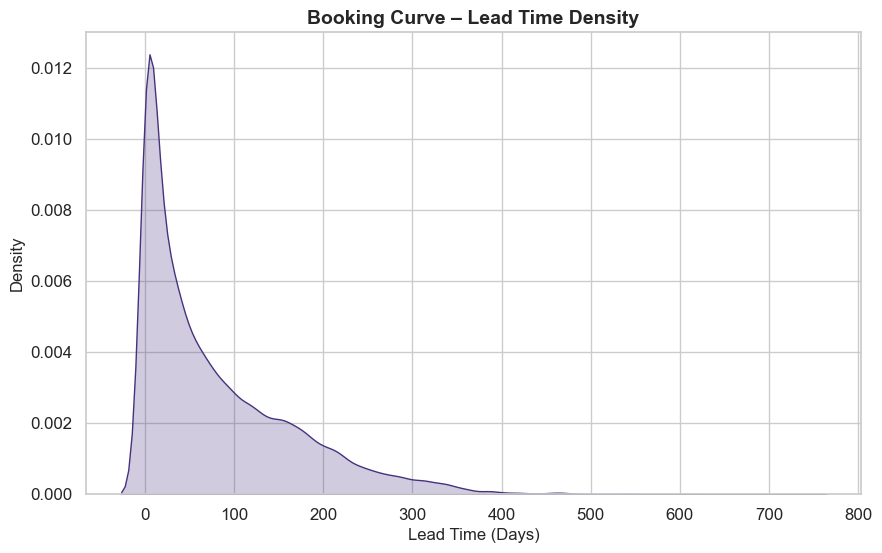

In [44]:
# 8. Booking Curve (Improved Density View)

plt.figure()
sns.kdeplot(
    df['lead_time'],
    fill=True
)

plt.title("Booking Curve – Lead Time Density")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Density")
plt.show()